In [2]:
!unzip /content/archive.zip -d /content/dataset

Archive:  /content/archive.zip
  inflating: /content/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [3]:
import os

print(os.listdir("/content/dataset"))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")

All imports successful ✓


In [7]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


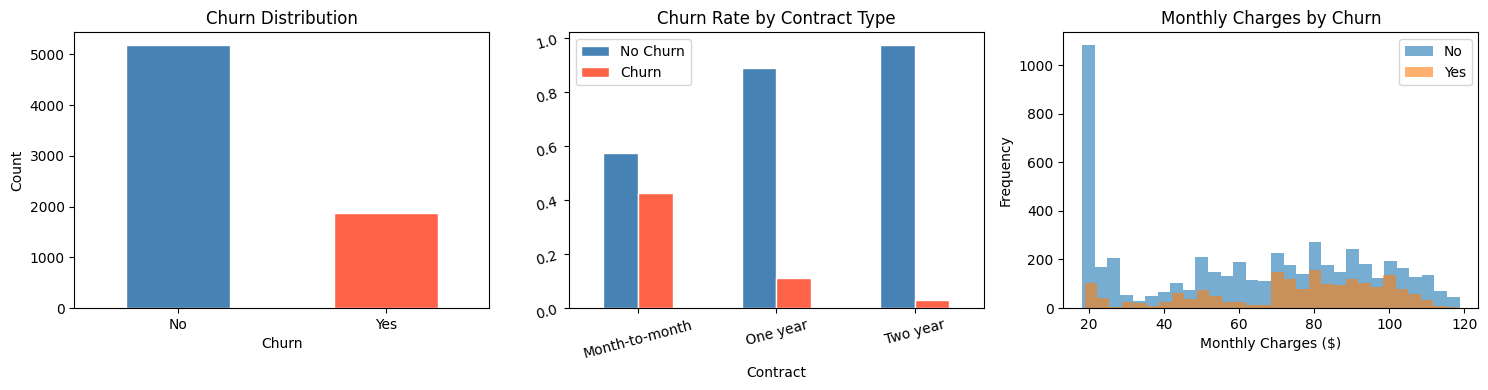

EDA plots saved ✓


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Churn by contract type
churn_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
churn_contract.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].tick_params(rotation=15)
axes[1].legend(['No Churn', 'Churn'])

# Monthly charges distribution
df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', ax=axes[2], alpha=0.6, bins=30, legend=True)
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved ✓")

In [9]:
# Drop customer ID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges — it's stored as string with some spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode binary target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Preprocessing done ✓")
print(f"Null values remaining: {df.isnull().sum().sum()}")
print(f"\nFeatures: {df.shape[1] - 1}  |  Samples: {df.shape[0]}")

Preprocessing done ✓
Null values remaining: 0

Features: 19  |  Samples: 7043


In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test:  {y_test.mean():.2%}")

Train size: 5634  |  Test size: 1409
Churn rate in train: 26.54%
Churn rate in test:  26.54%


In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8409


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8225


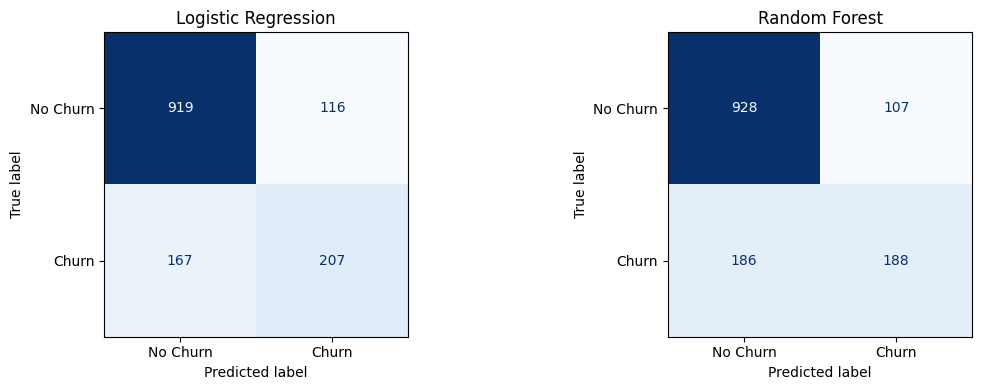

Confusion matrices saved ✓


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, name in zip(
    axes,
    [lr, rf],
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved ✓")

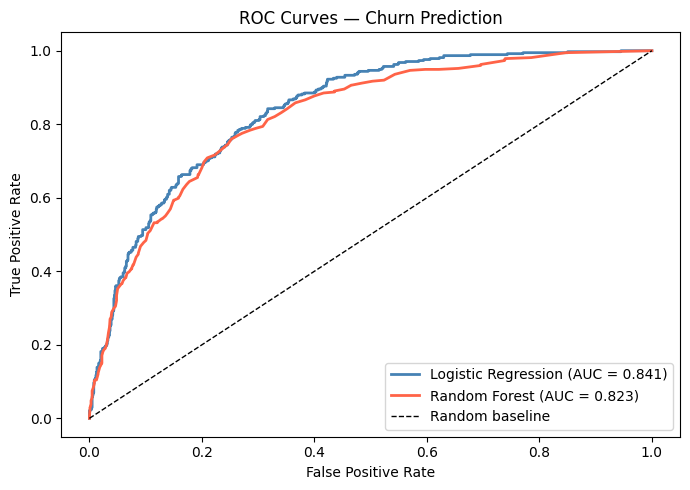

ROC curves saved ✓


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', 'steelblue'),
    (rf_proba, 'Random Forest', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Churn Prediction')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved ✓")

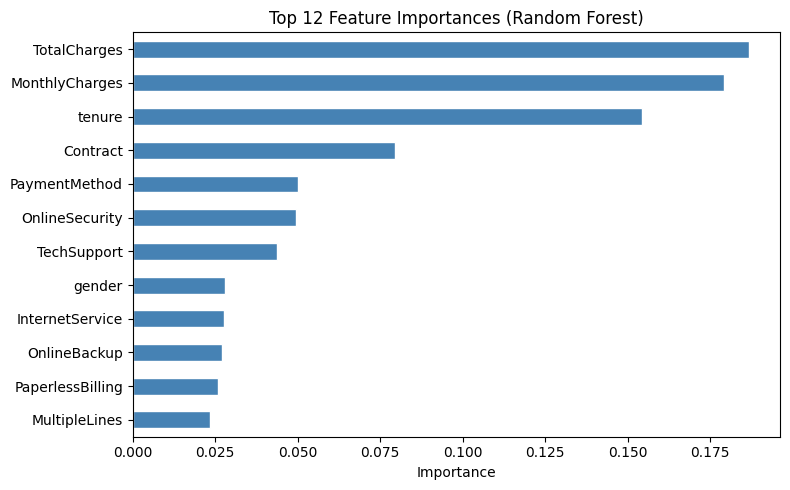

Feature importance saved ✓


In [15]:
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = feat_importance.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 12 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved ✓")

In [16]:
# This takes ~2-3 minutes to run
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"\nBest params: {grid_search.best_params_}")
print(f"Tuned ROC-AUC:   {roc_auc_score(y_test, best_proba):.4f}")
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(classification_report(y_test, best_preds, target_names=['No Churn', 'Churn']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Tuned ROC-AUC:   0.8384
Baseline ROC-AUC: 0.8225
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [17]:
print("=" * 45)
print("       FINAL MODEL COMPARISON")
print("=" * 45)
print(f"Logistic Regression ROC-AUC : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Random Forest ROC-AUC       : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Tuned Random Forest ROC-AUC : {roc_auc_score(y_test, best_proba):.4f}")
print("=" * 45)
print("\nSaved plots:")
print("  • eda_plots.png")
print("  • confusion_matrices.png")
print("  • roc_curves.png")
print("  • feature_importance.png")
print("\nProject 1 complete ✓")

       FINAL MODEL COMPARISON
Logistic Regression ROC-AUC : 0.8409
Random Forest ROC-AUC       : 0.8225
Tuned Random Forest ROC-AUC : 0.8384

Saved plots:
  • eda_plots.png
  • confusion_matrices.png
  • roc_curves.png
  • feature_importance.png

Project 1 complete ✓
